In [3]:
import pandana as pdna
import osmnx as ox
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [4]:
place = "Lyngby, Denmark"
G = ox.graph_from_place(place)
G = ox.project_graph(G)

nodes, edges = ox.graph_to_gdfs(G)
edges = edges.reset_index()

network = pdna.Network(
    nodes["x"],
    nodes["y"],
    edges["u"],
    edges["v"],
    edges[["length"]],
)


WALKING_SPEED_KMPH = 4
MAX_WALKING_TIME_MIN = 15
max_distance = WALKING_SPEED_KMPH * 1000 / 60 * MAX_WALKING_TIME_MIN  # meters

network.precompute(max_distance)

nodes_latlon = nodes.to_crs(4326)


In [5]:
# Config for POIs

# see https://wiki.openstreetmap.org/wiki/Map_Features
categories = {
    "education": {"amenity": ["school", "university"]},
    "health": {"amenity": ["hospital", "clinic"]},
    "grocery": {"shop": ["supermarket", "convenience"]},
    "leisure": {"leisure": ["park", "playground"]},
    "culture": {"amenity": ["theatre", "museum"]},
}

# Caching stores the results of our queries to overpass, so it improves time for subsequent runs.
# NOTE: if categories are changed, the cache should be cleared to avoid using previous results.
ox.settings.use_cache = True

poi_distances = {}

# NOTE: This loop is running a query for each category, which is VERY slow.
# For this area (Fredensborg), it takes about 6½ minutes to run.
# We can, however, optimize this by running a single query for all categories, but I didn't implement that yet.
for category, tags in categories.items():
    features = ox.features_from_place(place, tags)
    if features.empty:
        continue

    centroids = (
        features
        .to_crs(nodes.crs)
        .geometry
        .dropna()
        .centroid
    )

    if centroids.empty:
        continue

    network.set_pois(
        category,
        max_distance,
        1,
        centroids.x,
        centroids.y,
    )

    d = network.nearest_pois(
        max_distance,
        category,
        num_pois=1,
        max_distance=max_distance + 1,
    ).iloc[:, 0]

    poi_distances[category] = d

poi_distances = pd.DataFrame(poi_distances)

# Binary reachability per category (1 if reachable within 15 min, else 0)
poi_distances = poi_distances.reindex(columns=categories.keys())
reachable = (poi_distances <= max_distance).fillna(False).astype(int)
access_score = reachable.sum(axis=1)


In [10]:
result = pd.concat([reachable, access_score.rename("access_score")], axis=1)
print(result.head())
access_score.max()

            education  health  grocery  leisure  culture  access_score
osmid                                                                 
681891              0       1        1        0        0             2
34060289            0       1        1        0        0             2
8010326552          1       1        1        1        0             4
714758              1       1        1        1        0             4
2085505152          1       1        1        1        0             4


5

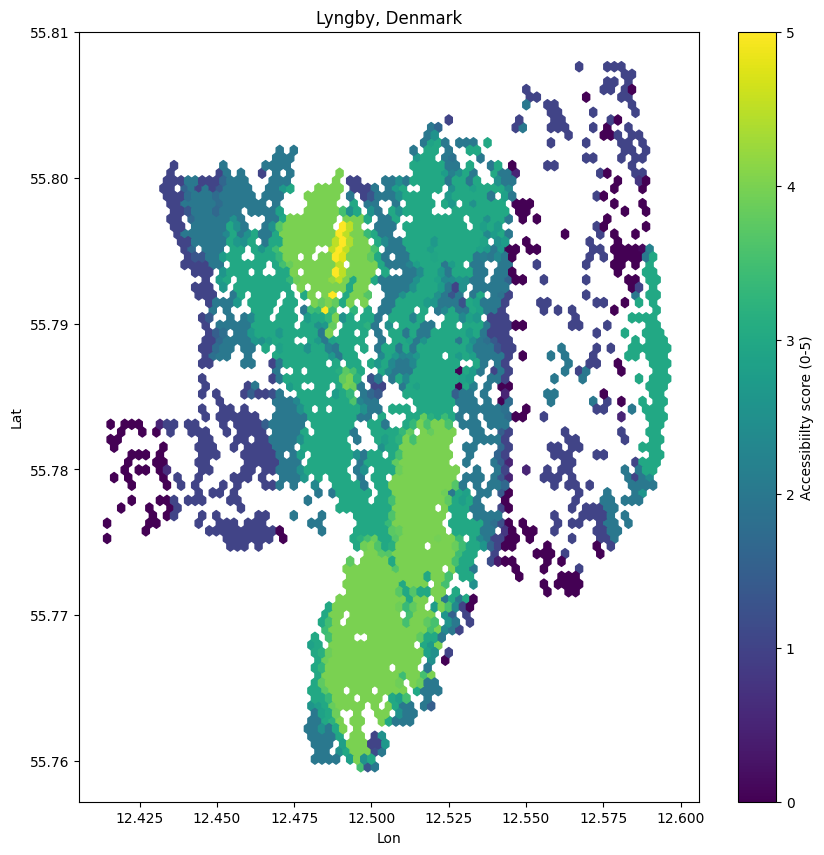

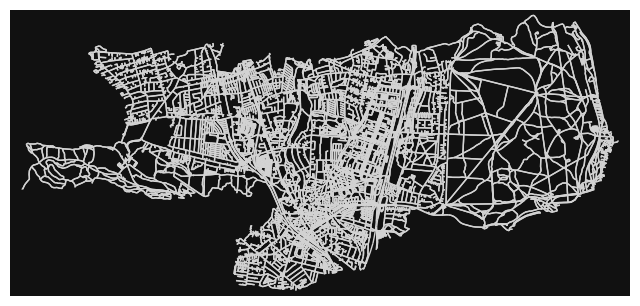

In [7]:
import matplotlib.pyplot as plt

x = nodes_latlon.geometry.x
y = nodes_latlon.geometry.y
z = access_score.loc[nodes_latlon.index] # get access score for each node

max_score = len(categories)

plot, ax = plt.subplots(figsize=(10, 10))
scatter = ax.hexbin(x, y, C=z, gridsize=80, cmap="viridis", vmin=0, vmax=max_score)
ax.set_title(f"{place}")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Accessibiilty score (0-5)")
plt.show()

# display the road network
fig, ax = ox.plot_graph(G, show=False, close=False, node_size=0, edge_color='lightgray')

In [12]:
# GeoJSON experiments
df = pd.DataFrame({
    "lat": nodes_latlon.geometry.y,
    "lon": nodes_latlon.geometry.x,
    "access_score": access_score.loc[nodes_latlon.index],
})

geom = [Point(xy) for xy in zip(df['lon'], df['lat'])]

gdf = gpd.GeoDataFrame(df, geometry=geom, crs=4326)
gdf.to_file("accessibility.json", driver="GeoJSON")